Device: mps
Loading GPCP...
  shape: (564, 72, 144)
  time: 1979-01-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
47 annual values
Clim global mean: 818.5 mm/yr
Global mean trend: 0.0495 mm/yr per yr
Regridded: (128, 192)
Saved gpcp_clim_rg.nc and gpcp_trend_rg.nc
Clim stats: mean=895.57  std=841.56

Loading finetuned ensemble...
  loaded member 0
  loaded member 1
  loaded member 2
  loaded member 3
  loaded member 4

── x0 = trend ──
  member 0 done
  member 1 done
  member 2 done
  member 3 done
  member 4 done

── x0 = noise ──
  member 0 done
  member 1 done
  member 2 done
  member 3 done
  member 4 done

── x0 = zeros ──
  member 0 done
  member 1 done
  member 2 done
  member 3 done
  member 4 done
Computing integration snapshots...
  trend: snapshots at t=[0.0, 0.25, 0.5, 0.75, 1.0]
  noise: snapshots at t=[0.0, 0.25, 0.5, 0.75, 1.0]
  zeros: snapshots at t=[0.0, 0.25, 0.5, 0.75, 1.0]
Saved all outputs to /Users/ewellmeyer/Documents/research/weights/flow_finetune_unet

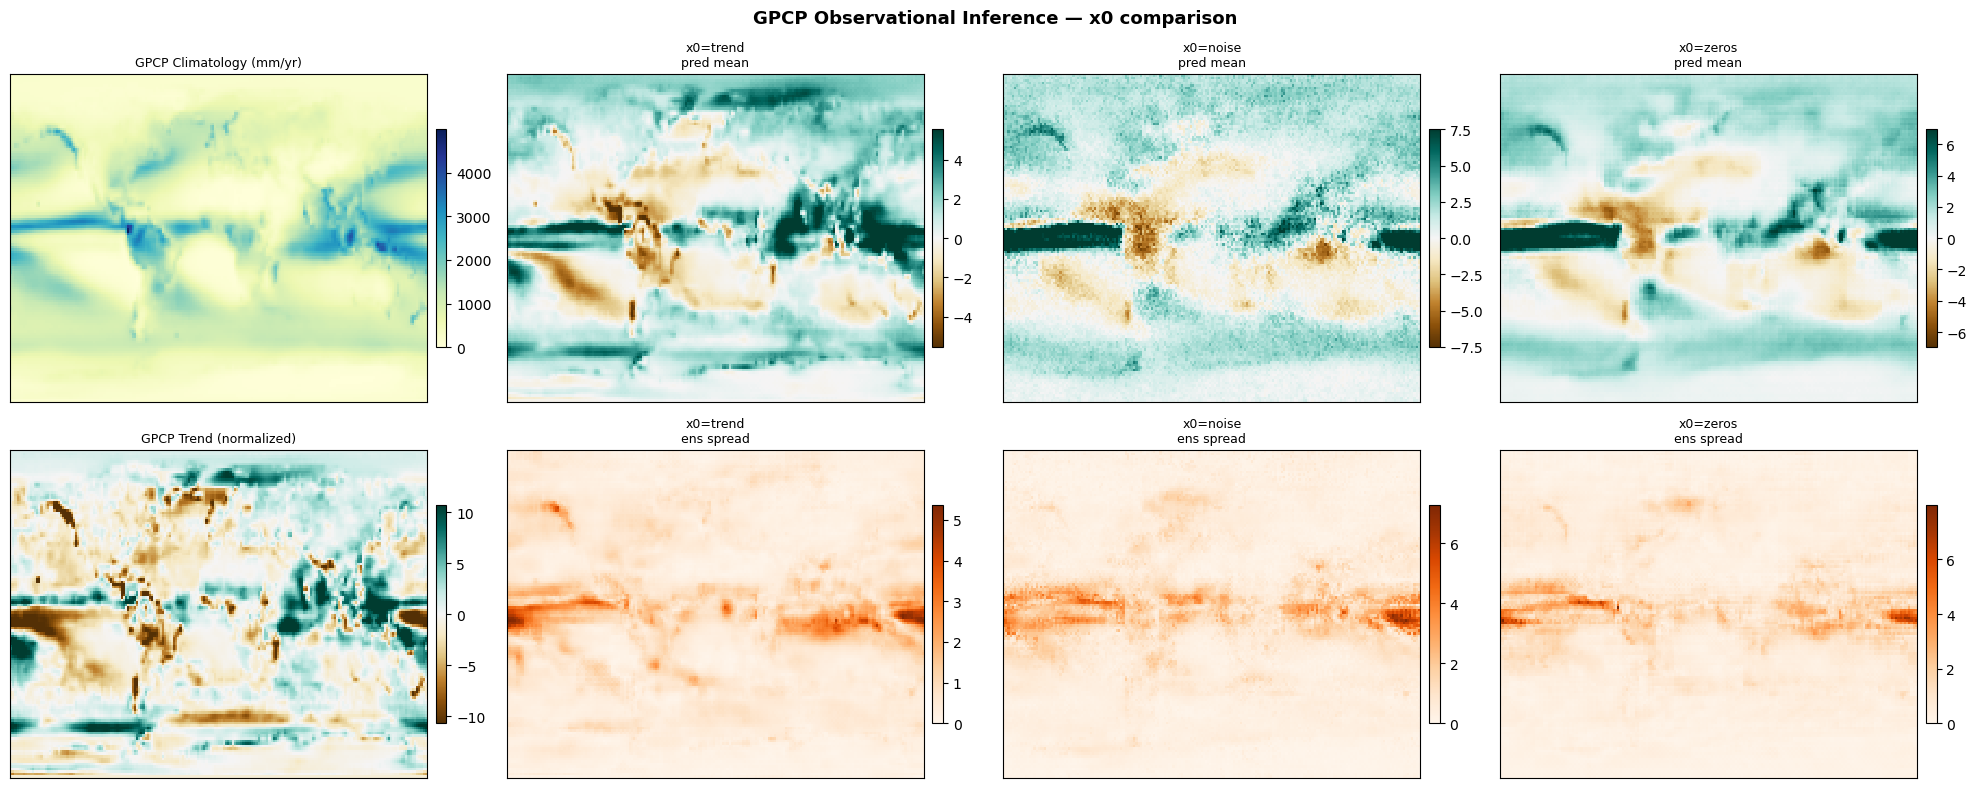

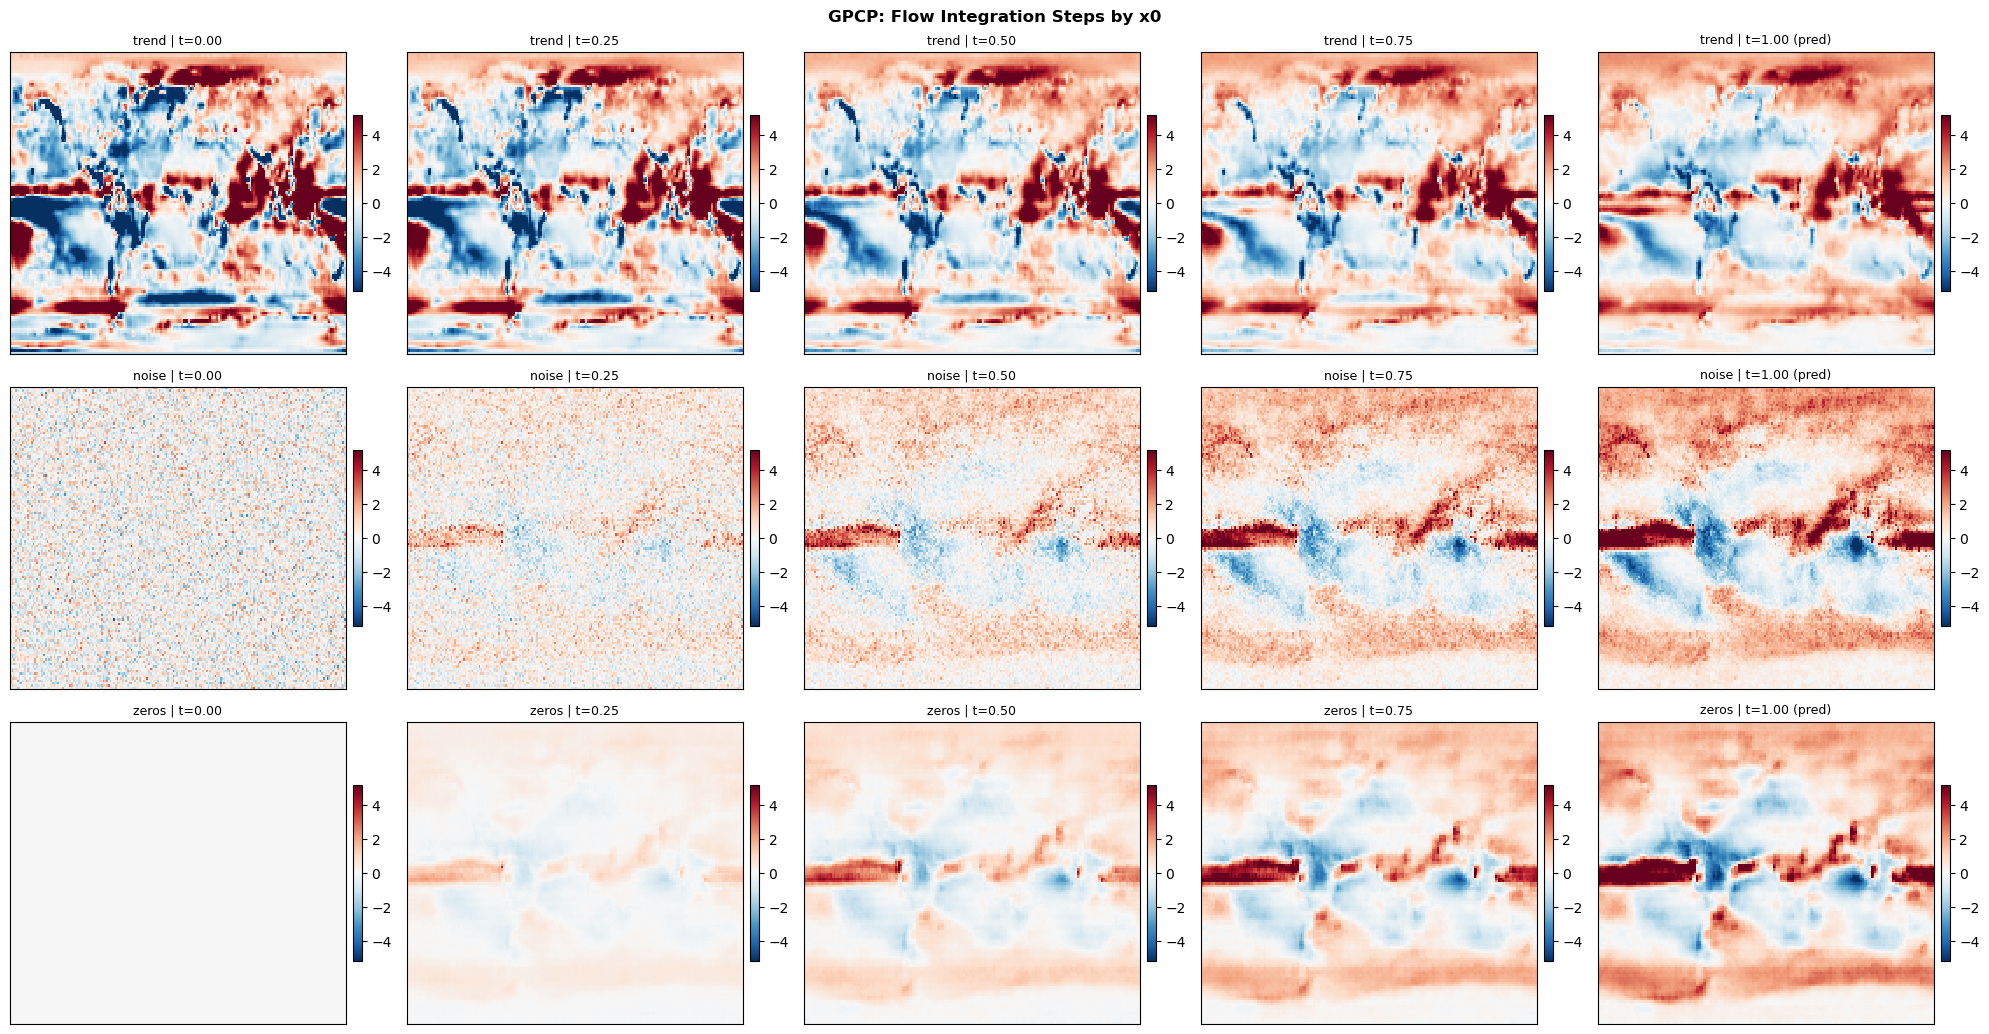

Done.


In [10]:
# %% [markdown]
# # GPCP Observational Inference
# Run the finetuned flow matching model on GPCP observations to predict
# future precipitation change from the observed historical mean state.

# %%
import json
from pathlib import Path

import numpy as np
import torch
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt

from flow_models import Unet6R

# ── configuration ──────────────────────────────────────────────────────────────

GPCP_PATH      = Path("/Users/ewellmeyer/Documents/research/GPCP/precip.mon.mean.nc")
LANDMASK_PATH  = Path("/Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc")
PPE_GRID_PATH  = Path("/Users/ewellmeyer/Documents/research/HadGEM/GA789_PR_his_rg128.nc")
WEIGHTS_DIR    = Path("/Users/ewellmeyer/Documents/research/weights")

BASE_CHANNELS  = 8

# FINETUNE_EXPT  = (f"flow_finetune_unet6R_ch{BASE_CHANNELS}_oce1.0_aug0.8")
FINETUNE_EXPT  = ("flow_finetune_unet6R_ch8_oce1.0_aug0.6_noise0.15_zero0.05")
FT_DIR         = WEIGHTS_DIR / FINETUNE_EXPT

BASE_EXPT      = f"flow_base_unet6R_ch{BASE_CHANNELS}_land10_oce0.3_aug0.8"
BASE_DIR       = WEIGHTS_DIR / BASE_EXPT

OUT_DIR        = FT_DIR / "gpcp_inference"
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_ENSEMBLE     = 5
ODE_STEPS      = 100
DT             = 1.0   # integration endpoint: 0 → DT (default 1.0 = full flow)
P_DROP         = 0.0
CONV           = 365.25   # mm/day -> mm/yr
NOISE_SEED     = 42

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")


# %%
@torch.no_grad()
def integrate(model, x0, clim, steps=20, dt_end=1.0):
    x = x0.clone()
    dt = dt_end / steps
    for i in range(steps):
        t_val = i * dt
        t = torch.full((x.shape[0],), t_val, device=x.device)
        v = model(x, clim, t)
        x = x + v * dt
    return x


def load_target_grid():
    ds = xr.open_dataset(PPE_GRID_PATH)
    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"
    lat = ds.coords[lat_name].values.astype(np.float64)
    lon = ds.coords[lon_name].values.astype(np.float64)
    ds.close()
    return lat, lon


# %% [markdown]
# ## Load and process GPCP

# %%
print("Loading GPCP...")
ds = xr.open_dataset(GPCP_PATH, drop_variables=["time_bnds", "lat_bnds", "lon_bnds"])
pr = ds["precip"] * CONV   # mm/day -> mm/yr
pr.attrs["units"] = "mm/yr"

# lon to [-180, 180)
lon = pr.coords["lon"].values
if lon.max() > 180:
    pr = pr.assign_coords(lon=((pr.coords["lon"] + 180) % 360) - 180)
    pr = pr.sortby("lon")

# lat ascending
if pr.coords["lat"].values[0] > pr.coords["lat"].values[-1]:
    pr = pr.sortby("lat")

print(f"  shape: {pr.shape}")
print(f"  time: {pr.time.values[0]} to {pr.time.values[-1]}")

# %%
# annual means
pr_ann = pr.resample(time="YS").mean("time")
pr_ann = pr_ann.assign_coords(time=pr_ann.time.dt.year.values)
print(f"{len(pr_ann.time)} annual values")

# climatology (full period)
clim = pr_ann.mean("time")
print(f"Clim global mean: {float(clim.mean()):.1f} mm/yr")

# linear trend
t_arr = np.arange(len(pr_ann.time), dtype=float)
pr_ann_indexed = pr_ann.assign_coords(time=t_arr)
p = pr_ann_indexed.polyfit(dim="time", deg=1)
trend = p["polyfit_coefficients"].sel(degree=1).drop_vars("degree")

# normalize by global mean trend
weights = np.cos(np.deg2rad(trend.lat))
gm_trend = float(trend.weighted(weights).mean(("lat", "lon")))
print(f"Global mean trend: {gm_trend:.4f} mm/yr per yr")
trend_norm = trend / gm_trend if abs(gm_trend) > 1 else trend

# %% [markdown]
# ## Regrid to PPE grid

# %%
target_lat, target_lon = load_target_grid()
ds_out = xr.Dataset({"lat": ("lat", target_lat), "lon": ("lon", target_lon)})

regridder = xe.Regridder(clim, ds_out, method="bilinear",
                         periodic=True, reuse_weights=False)

clim_rg  = regridder(clim)
trend_rg = regridder(trend_norm)
print(f"Regridded: {clim_rg.shape}")

# save
xr.Dataset({"pr_clim": clim_rg},
           attrs={"units": "mm/yr", "source": "GPCP v2.3"}
           ).to_netcdf(OUT_DIR / "gpcp_clim_rg.nc")
xr.Dataset({"pr_trend": trend_rg},
           attrs={"units": "dimensionless", "source": "GPCP v2.3"}
           ).to_netcdf(OUT_DIR / "gpcp_trend_rg.nc")
print("Saved gpcp_clim_rg.nc and gpcp_trend_rg.nc")

# %% [markdown]
# ## Load models and run inference

# %%
# clim stats
stats_path = FT_DIR / "clim_stats.json"
if not stats_path.exists():
    stats_path = BASE_DIR / "clim_stats.json"
with open(stats_path) as f:
    stats = json.load(f)
clim_mean, clim_std = stats["clim_mean"], stats["clim_std"]
print(f"Clim stats: mean={clim_mean:.2f}  std={clim_std:.2f}")

# load ensemble
print("\nLoading finetuned ensemble...")
models = []
for mi in range(N_ENSEMBLE):
    p = FT_DIR / f"best_member{mi}.pth"
    if not p.exists():
        print(f"  member {mi}: not found"); continue
    ckpt = torch.load(p, map_location=DEVICE)
    m = Unet6R(input_channels=2, output_channels=1,
               base_channels=BASE_CHANNELS, p_drop=P_DROP).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"]); m.eval()
    models.append((mi, m))
    print(f"  loaded member {mi}")

# %%
# prepare conditioning tensor and x0 variants
clim_np  = clim_rg.values.astype(np.float32)
trend_np = trend_rg.values.astype(np.float32)

clim_norm_np = np.nan_to_num((clim_np - clim_mean) / (clim_std + 1e-6))
clim_t = torch.from_numpy(clim_norm_np[None, None]).float().to(DEVICE)

# three initial conditions to compare
rng = np.random.default_rng(NOISE_SEED)
shape = trend_np.shape

x0_variants = {
    "trend":  torch.from_numpy(np.nan_to_num(trend_np)[None, None]).float().to(DEVICE),
    "noise":  torch.from_numpy(rng.standard_normal((1, 1, *shape)).astype(np.float32)).to(DEVICE),
    "zeros":  torch.zeros(1, 1, *shape, device=DEVICE),
}

# %%
# run ensemble for each initial condition
results = {}  # key -> {"mean": ..., "std": ..., "preds": [...]}

for x0_name, x0_t in x0_variants.items():
    print(f"\n── x0 = {x0_name} ──")
    preds = []
    for mi, m in models:
        pred = integrate(m, x0_t, clim_t, steps=ODE_STEPS, dt_end=DT)
        preds.append(pred.cpu().numpy()[0, 0])
        print(f"  member {mi} done")
    results[x0_name] = {
        "mean": np.mean(preds, axis=0),
        "std":  np.std(preds,  axis=0),
        "preds": preds,
    }

# %%
# integration steps for visualization (using first model, all three x0s)
print("Computing integration snapshots...")
vis_times = [t * DT for t in [0.0, 0.25, 0.5, 0.75, 1.0]]
_, m0 = models[0]
step_fields = {}  # x0_name -> {t_val: array}

for x0_name, x0_t in x0_variants.items():
    x = x0_t.clone()
    dt = DT / ODE_STEPS
    sf = {0.0: x.cpu().numpy()[0, 0].copy()}
    with torch.no_grad():
        for i in range(ODE_STEPS):
            t_val = i * dt
            t = torch.full((1,), t_val, device=DEVICE)
            v = m0(x, clim_t, t)
            x = x + v * dt
            t_after = (i + 1) * dt
            for vs in vis_times:
                if abs(t_after - vs) < dt / 2 and vs not in sf:
                    sf[vs] = x.cpu().numpy()[0, 0].copy()
    step_fields[x0_name] = sf
    print(f"  {x0_name}: snapshots at t={sorted(sf.keys())}")

# %%
# save outputs for each condition
coords = {"lat": target_lat, "lon": target_lon}

for x0_name, res in results.items():
    xr.Dataset(
        {"dPdP_pred": (("lat", "lon"), res["mean"])},
        coords=coords,
        attrs={"source": "GPCP v2.3", "model": FINETUNE_EXPT,
               "x0": x0_name, "n_ensemble": len(models), "ode_steps": ODE_STEPS,
               "dt_end": DT}
    ).to_netcdf(OUT_DIR / f"gpcp_pred_dPdP_{x0_name}.nc")

    xr.Dataset(
        {"dPdP_std": (("lat", "lon"), res["std"])},
        coords=coords,
        attrs={"x0": x0_name}
    ).to_netcdf(OUT_DIR / f"gpcp_pred_std_{x0_name}.nc")

    sf = step_fields[x0_name]
    step_das = {}
    for t_val, field in sorted(sf.items()):
        step_das[f"xt_{int(t_val*100):03d}"] = (("lat", "lon"), field)
    xr.Dataset(step_das, coords=coords).to_netcdf(
        OUT_DIR / f"gpcp_integration_steps_{x0_name}.nc")

print(f"Saved all outputs to {OUT_DIR}")

# %% [markdown]
# ## Diagnostic plots

# %%
def plot_field(ax, data, title, cmap="RdBu_r", vmin=None, vmax=None,
               symmetric=False):
    if symmetric:
        vmax = vmax or np.nanpercentile(np.abs(data), 98)
        vmin = -vmax
    im = ax.imshow(data, origin="lower", cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect="auto",
                   interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)

# %%
# summary: inputs + ensemble mean for each x0 condition
n_conds = len(results)
fig, axes = plt.subplots(2, n_conds + 1, figsize=(5 * (n_conds + 1), 8))
fig.suptitle("GPCP Observational Inference — x0 comparison", fontsize=13, fontweight="bold")

# shared inputs (column 0)
plot_field(axes[0, 0], clim_np, "GPCP Climatology (mm/yr)", cmap="YlGnBu", vmin=0)
plot_field(axes[1, 0], trend_np, "GPCP Trend (normalized)", cmap="BrBG", symmetric=True)

for col, x0_name in enumerate(results, start=1):
    res = results[x0_name]
    plot_field(axes[0, col], res["mean"],
               f"x0={x0_name}\npred mean", cmap="BrBG", symmetric=True)
    plot_field(axes[1, col], res["std"],
               f"x0={x0_name}\nens spread", cmap="Oranges", vmin=0)

plt.tight_layout()
# fig.savefig(OUT_DIR / "gpcp_x0_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# %%
# integration strips — one row per x0 condition
t_keys = sorted(next(iter(step_fields.values())).keys())
fig, axes = plt.subplots(n_conds, len(t_keys),
                         figsize=(4 * len(t_keys), 3.5 * n_conds))
if n_conds == 1:
    axes = axes[np.newaxis, :]

# use a common scale across conditions for easy comparison
all_preds = np.stack([results[k]["mean"] for k in results])
vmax = float(np.nanpercentile(np.abs(all_preds), 97))

for row, x0_name in enumerate(results):
    sf = step_fields[x0_name]
    for col, t_val in enumerate(t_keys):
        label = f"t={t_val:.2f}" if t_val < DT else f"t={t_val:.2f} (pred)"
        plot_field(axes[row, col], sf[t_val],
                   f"{x0_name} | {label}",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax)

fig.suptitle("GPCP: Flow Integration Steps by x0", fontsize=12, fontweight="bold")
plt.tight_layout()
# fig.savefig(OUT_DIR / "gpcp_integration_strips.png", dpi=150, bbox_inches="tight")
plt.show()

print("Done.")